# Week 13 - Bivariate Analysis 2 - Statistics

# 

# 1. Lesson

We are going to consider some statistical tests that you can apply to your data.

### T-tests

You can use a t-test to discern whether the means of two sets of numbers might be the same.  The t-test is useful for data that are normally distributed.  The data should also have approximately equal variances.  Of course you can run a t-test for data that don't fit these criteria, but the less well it fits, the more likely that the t-test will give the wrong result.

First, here is a one-sample t-test to see if you have made a correct guess about the underlying mean:

In [1]:
from scipy import stats
import numpy as np
np.random.seed(0)
arr1 = np.random.normal(loc = 0, size = 1000)
t_stat, p_value = stats.ttest_1samp(arr1, 0)
# The array might have a mean of 0; p > 0.05.  In fact, it does have a mean of 0.
print(p_value)

0.14759031545459378


In [2]:
# The array probably does not have a mean of 0.1; p < 0.05.  In fact, it doesn't.
t_stat, p_value = stats.ttest_1samp(arr1, 0.1)
print(p_value)

3.7389682463533562e-06


In [3]:
arr2 = np.random.normal(loc = 0, size = 10)
t_stat, p_value = stats.ttest_1samp(arr2, 0.1)
# This array might have a mean of 0.1; p > 0.05.  In fact, it doesn't - but since there are only ten samples, we can't tell that
print(p_value)

0.8283790364046455


In [4]:
arr3 = np.random.normal(loc = 0.1, size = 1000)
t_stat, p_value = stats.ttest_ind(arr1, arr3)
# The two arrays probably have different means; p < 0.05.  In fact, they do have different means; 0 and 0.1
print(p_value)

0.0004525039970281393


### Mann-Whitney U-test

This test is used to determine whether two sets of numbers might come from the same distribution - but without making any assumptions about the data being normally distributed.

In [5]:
u_value, p_value = stats.mannwhitneyu(arr1, arr3)
# The two arrays probably come from different distributions.  In fact, they do; one comes from mean = 0, one mean = 1.
print(p_value)

0.0006158714688322862


In [6]:
np.random.seed(0)
arr4 = np.concatenate([np.zeros(10) + 0.01, np.array([1])])
arr5 = np.concatenate([np.zeros(10) - 0.01, np.array([-1])])
t_stat, p_value = stats.ttest_ind(arr4, arr5)
# Here is an example where the t-test fails due to the non-normality of the data.  The data do come from different 
# distributions with different means, but the t-test fails to detect it.
print(p_value)

0.13178840154670063


In [7]:
u_value, p_value = stats.mannwhitneyu(arr4, arr5)
# The two arrays probably come from different distributions.  In fact, they do; see above.
# It is unusual for the t-test to fail due to non-normality but the Mann-Whitney U-test to succeed, but it can happen as in this case.
print(p_value)

1.2550539978736685e-05


### ANOVA: categorical data plotted vs. continous data

ANOVA is a t-test generalized to more than two groups

In [8]:
np.random.seed(0)
arr6 = np.random.normal(loc = 0, size = 1000)
arr7 = np.random.normal(loc = 0.1, size = 1000)
arr8 = np.random.normal(loc = 0.2, size = 1000)
result = stats.f_oneway(arr1, arr3, arr6)
# The three arrays probably have different means; p < 0.05.  In fact, as you can see, they do have different means.
print(result.pvalue)

0.00028601982658831227


### Chi-square: categorical data plotted vs. categorical data

Chi-square will test for statistical independence between counts for two categorical features.  To do this, it requires a matrix of numbers: one feature corresponds to the row and one to the column.  The numbers must be counts.  Thus, if the category for the column is weather (cloudy or sunny) and the category for the row is temperature (low, medium, or high), then the count of days in the month at that temperature and weather would be a good variable for chi-square.

In [9]:
arr9 = np.array([[10, 0], [5, 5], [0, 10]])
result = stats.chi2_contingency(arr9)
# Different rows are very different.  Each row is _not_ a fixed multiple of each other, so the variables are not independent.
# Thus, the chi-squared test shows that the data are not independent.  
# In the next example, we will elaborate on what kind of difference is involved
print(result.pvalue)

4.539992976248486e-05


The specific goal of the chi-squared contingency table test is to find out whether the table possesses statistical independence - which is to say, it asks whether each number can be written as a product of two other numbers: one for its row and one for its column.  For example, suppose two stores, A and B, sell two kinds of apples, red and green.  If the number of apples sold is independent, it would mean that we can multiply to get the number sold.  That is, the fraction of the apples that are red and sold at store A would approximately equal the fraction red multiplied by the fraction sold at store A.

In [10]:
A_B_values = np.array([0.4, 0.6])
red_green_values = np.array([0.7, 0.3])
outer_product = 50 * np.outer(A_B_values, red_green_values)
print(outer_product)

[[14.  6.]
 [21.  9.]]


The chi-squared test returns a null result due to the complete independence of the values.  (p > 0.05).  Each row is precisely a fixed multiple of the other.  As above, a low p-value means dependence and a high p-value means independence.

In [11]:
result = stats.chi2_contingency(outer_product)
print(result.pvalue)

1.0


In [12]:
arr9 = np.array([[10, 0], [9, 1], [8, 2]])
result = stats.chi2_contingency(arr9)
# Here, the first columns (10, 9, 8) is quite different in its ratios compared with the second (0, 1, 2)
# However, because the second column has low counts, it is conceivable that these ratios could not be the true ratios.
# This means that perhaps the variables are independent after all, leading to a relatively high p-value - we cannot say for
# sure that the data are not independent.  We'd need more data to say that.
print(result.pvalue)

0.3291929878079055


In [13]:
result = stats.chi2_contingency(arr9 * 3)
# If we have a lot more data, even with the exact same ratios between the rows, we become more certain that the data are not independent
print(arr9 * 3)
print(result.pvalue)

[[30  0]
 [27  3]
 [24  6]]
0.035673993347252395


# 2. Weekly graph question

Which of the following graph color schemes would you choose, and why?

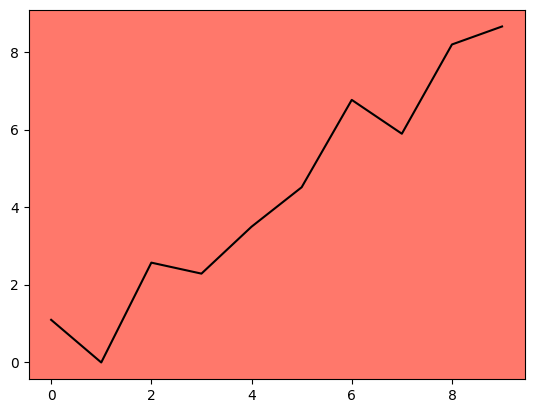

In [18]:
import matplotlib.pyplot as plt
arr10 = np.arange(10)
arr11 = np.random.normal(size = 10) + np.arange(10)
fig = plt.plot(arr10, arr11, c = "black")
ax = plt.gca()
ax.set_facecolor((1.0, 0.47, 0.42))

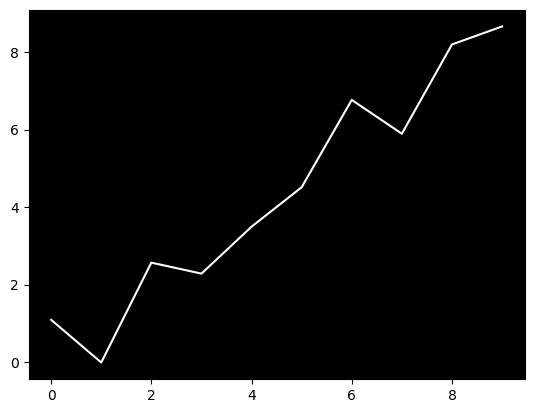

In [19]:
fig = plt.plot(arr10, arr11, c = "white")
ax = plt.gca()
ax.set_facecolor((0, 0, 0))

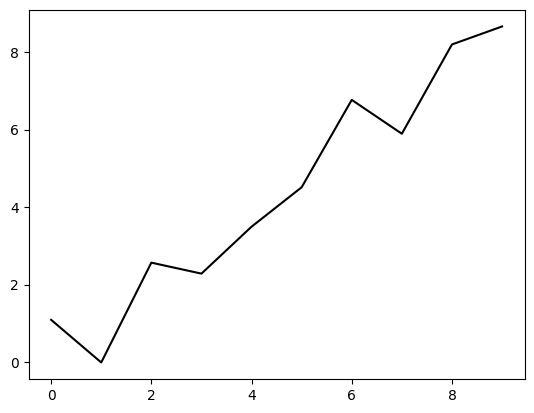

In [20]:
fig = plt.plot(arr10, arr11, c = "black")
ax = plt.gca()
ax.set_facecolor((1, 1, 1))

I would select the third color scheme, the black line with a white background. This color scheme provides the greatest contrast, making the graph accessible to those with visual impairments and causing the trends to be immediately visible. The non-white backgrounds of the other color scheme options are quite busy and affect the graph's legibility. 

# 3. Homework

* Create a dataset showing flowers that have been fertilized with two brands of fertilizer.  The data show the heights of the flowers.  One fertilizer is better than the other, leading to taller flowers - but only slightly taller.
* The flowers have some height distribution that is _not_ normal.
* Use a t-test and a Mann-Whitney U test to determine whether the flowers have the same height.  (In this case, try the t-test even though the distribution it not normal.  However, that is not always a good idea!)
* Actually, create two datasets: one where the t-test works (and detects the slight height difference) and one where the t-test fails.
* Draw a box and whisker plot or histogram showing the distribution of the flower heights in each case.  Can you see the difference?
* Next, create a dataset showing five different brands of fertilizer, leading to five somewhat different height distributions.  Use an ANOVA test to detect the height differences.  Does the ANOVA test work?
* Finally, create a dataset showing the heights of four different flower types for each of the five brand of fertilizers (one height for each pair, so 4 x 5 = 20 heights).  Use a chi squared test to check whether the five different fertilizers lead to different flower heights.

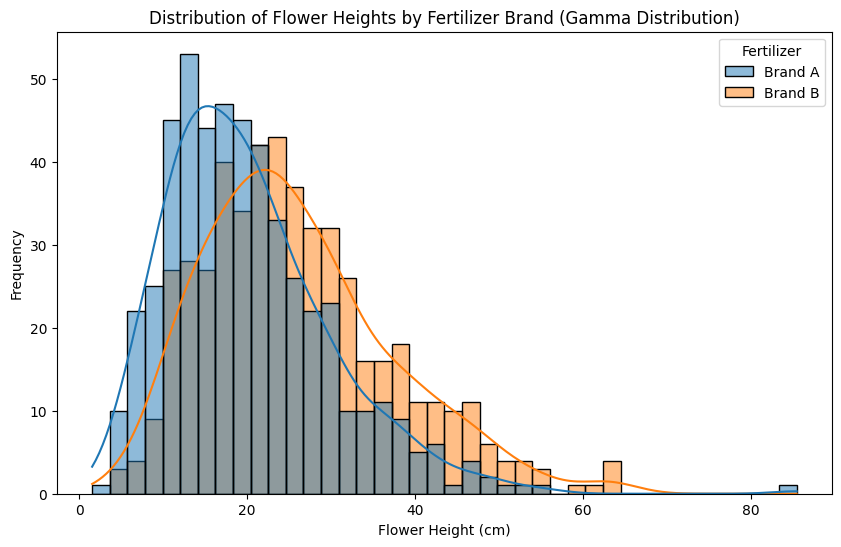

,Fertilizer,Height_cm
0,Brand A,23.512069
1,Brand A,17.041160
2,Brand A,16.181624
3,Brand A,16.181768
4,Brand A,37.990551


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# creata a non-normal dataset of flower heights for two different fertilizer brands (Brand A and Brand B)
# Set random seed for reproducibility
np.random.seed(42)

# Number of flowers per brand
n_samples = 500

# Generate non-normal data using a Gamma distribution (right-skewed)

# Brand A (Mean = shape * scale = 4.0 * 5.0 = 20)
heights_a = np.random.gamma(shape=4.0, scale=5.0, size=n_samples)

# Brand B (Slightly better fertilizer) (Mean = shape * scale = 4.5 * 5.0 = 22.5)
heights_b = np.random.gamma(shape=5.0, scale=5.0, size=n_samples)

# Combine into a pandas DataFrame
df_flowers = pd.DataFrame({
    'Fertilizer': ['Brand A'] * n_samples + ['Brand B'] * n_samples,
    'Height_cm': np.concatenate([heights_a, heights_b])
})

# Visualization
plt.figure(figsize=(10, 6))

# Plot the overlapping histograms with density curves
sns.histplot(
    data=df_flowers, 
    x='Height_cm', 
    hue='Fertilizer', 
    kde=True,          # Add smooth line 
    bins=40, 
    alpha=0.5,
    palette=['#1f77b4', '#ff7f0e'] 
)

plt.title('Distribution of Flower Heights by Fertilizer Brand (Gamma Distribution)')
plt.xlabel('Flower Height (cm)')
plt.ylabel('Frequency')
plt.show()

# Show the first few rows
df_flowers.head()

In [ ]:
from scipy import stats

print("--- Dataset 1: The T-Test Works (Moderate Non-Normal Skew) ---")

t_stat_1, p_val_t_1 = stats.ttest_ind(heights_b, heights_a, equal_var=False)
u_stat_1, p_val_u_1 = stats.mannwhitneyu(heights_b, heights_a, alternative='two-sided')

print(f"T-test p-value:          {p_val_t_1:.5f} (Significant difference detected)")
print(f"Mann-Whitney U p-value:  {p_val_u_1:.5f} (Significant difference detected)\n")


print("--- Dataset 2: The T-Test Fails (Extreme Outliers) ---")

heights_a_outliers = np.append(heights_a, [500, 600, 700]) # Outliers
heights_b_outliers = np.append(heights_b, [20, 22, 25])    # Normal additions

t_stat_2, p_val_t_2 = stats.ttest_ind(heights_b_outliers, heights_a_outliers, equal_var=False)
u_stat_2, p_val_u_2 = stats.mannwhitneyu(heights_b_outliers, heights_a_outliers, alternative='two-sided')

print(f"T-test p-value:          {p_val_t_2:.5f} (Failed to detect true difference due to outliers)")
print(f"Mann-Whitney U p-value:  {p_val_u_2:.5f} (Significant difference detected)")

--- Dataset 1: The T-Test Works (Moderate Non-Normal Skew) ---
T-test p-value:          0.00000 (Significant difference detected)
Mann-Whitney U p-value:  0.00000 (Significant difference detected)

--- Dataset 2: The T-Test Fails (Extreme Outliers) ---
T-test p-value:          0.24352 (Failed to detect true difference due to outliers)
Mann-Whitney U p-value:  0.00000 (Significant difference detected)


c:\Users\santo\OneDrive\Documents\GitHub\Learning\.venv\Lib\site-packages\seaborn\_base.py:1447: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  self.plot_data[axis] = cat_data
C:\Users\santo\AppData\Local\Temp\ipykernel_15240\966713614.py:24:

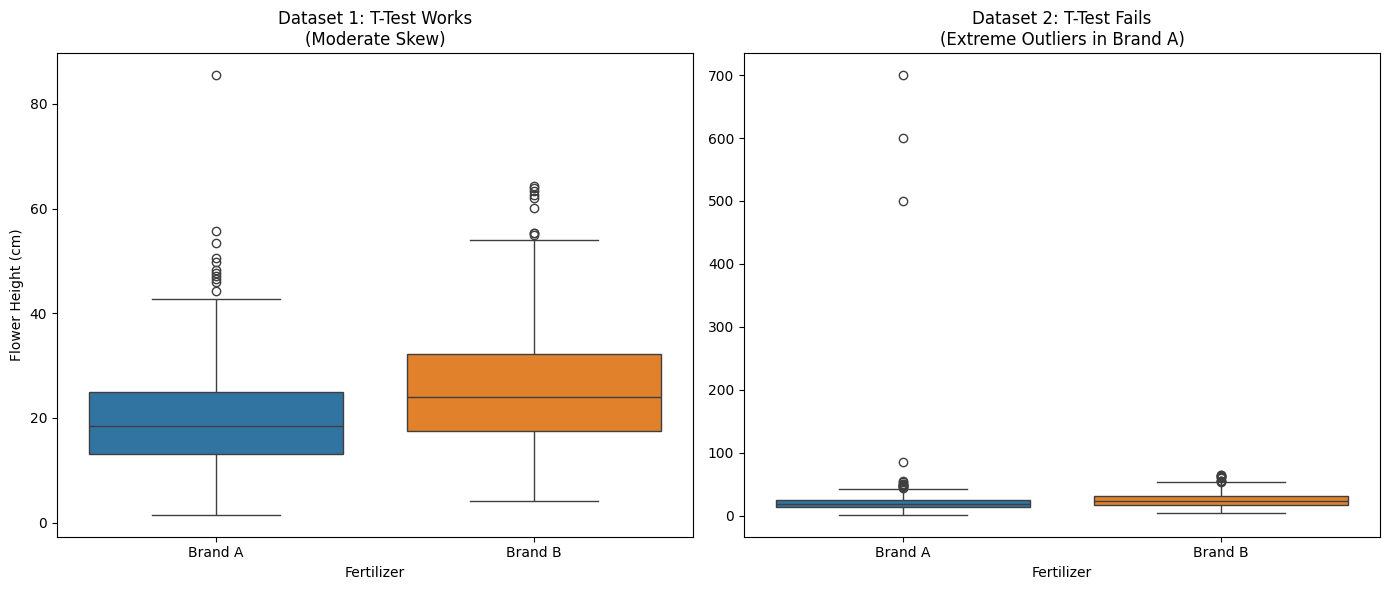

In [ ]:
# Visualization: Box and Whisker plots for both datasets
import seaborn as sns
import matplotlib.pyplot as plt

# Prepare data for plotting
import pandas as pd

# Dataset 1: Moderate Non-Normal Skew (T-Test works)
df_1 = pd.DataFrame({
    'Fertilizer': ['Brand A'] * len(heights_a) + ['Brand B'] * len(heights_b),
    'Height_cm': np.concatenate([heights_a, heights_b])
})

# Dataset 2: Extreme Outliers (T-Test fails)
df_2 = pd.DataFrame({
    'Fertilizer': ['Brand A'] * len(heights_a_outliers) + ['Brand B'] * len(heights_b_outliers),
    'Height_cm': np.concatenate([heights_a_outliers, heights_b_outliers])
})

# Set up the figure with 2 system plots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1
sns.boxplot(data=df_1, x='Fertilizer', y='Height_cm', ax=axes[0], palette=['#1f77b4', '#ff7f0e'])
axes[0].set_title('Dataset 1: T-Test Works\n(Moderate Skew)')
axes[0].set_ylabel('Flower Height (cm)')

# Plot 2
sns.boxplot(data=df_2, x='Fertilizer', y='Height_cm', ax=axes[1], palette=['#1f77b4', '#ff7f0e'])
axes[1].set_title('Dataset 2: T-Test Fails\n(Extreme Outliers in Brand A)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

--- One-way ANOVA Results ---
F-statistic: 13.8448
p-value:     4.30916e-11
Conclusion: The ANOVA test WORKS and detected a statistically significant difference in height across the 5 fertilizer brands!


c:\Users\santo\OneDrive\Documents\GitHub\Learning\.venv\Lib\site-packages\seaborn\_base.py:1447: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  self.plot_data[axis] = cat_data
C:\Users\santo\AppData\Local\Temp\ipykernel_15240\3698329212.py:32

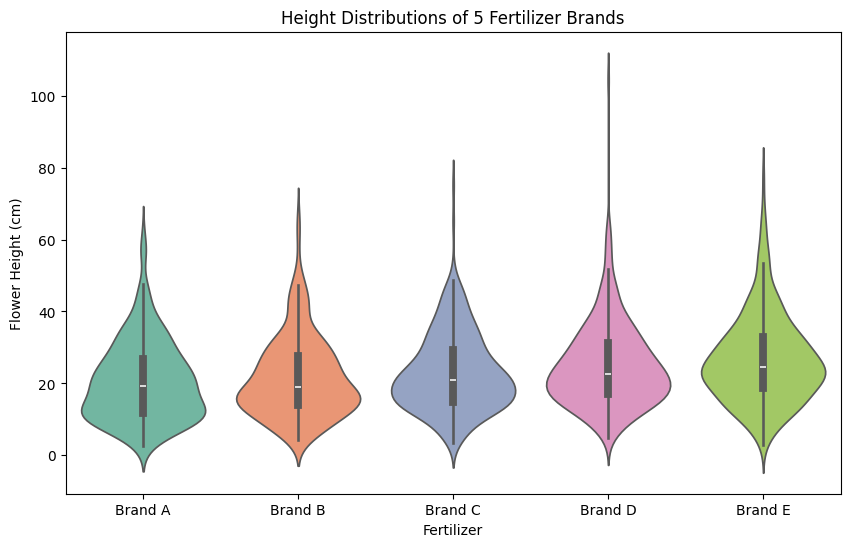

In [6]:
# Generate 5 different non-normal distributions (Gamma)
np.random.seed(101)
n_anova = 300

# Generate Gamma distributions with varying shapes (increasing means)
dist_a = np.random.gamma(shape=4.0, scale=5.0, size=n_anova) # Mean ~ 20.0
dist_b = np.random.gamma(shape=4.2, scale=5.0, size=n_anova) # Mean ~ 21.0
dist_c = np.random.gamma(shape=4.5, scale=5.0, size=n_anova) # Mean ~ 22.5
dist_d = np.random.gamma(shape=4.8, scale=5.0, size=n_anova) # Mean ~ 24.0
dist_e = np.random.gamma(shape=5.0, scale=5.0, size=n_anova) # Mean ~ 25.0

# Store in a dataframe
df_anova = pd.DataFrame({
    'Fertilizer': ['Brand A']*n_anova + ['Brand B']*n_anova + ['Brand C']*n_anova + ['Brand D']*n_anova + ['Brand E']*n_anova,
    'Height_cm': np.concatenate([dist_a, dist_b, dist_c, dist_d, dist_e])
})

# Perform One-way ANOVA
f_stat, p_value_anova = stats.f_oneway(dist_a, dist_b, dist_c, dist_d, dist_e)

print("--- One-way ANOVA Results ---")
print(f"F-statistic: {f_stat:.4f}")
print(f"p-value:     {p_value_anova:.5e}")

if p_value_anova < 0.05:
    print("Conclusion: The ANOVA test WORKS and detected a statistically significant difference in height across the 5 fertilizer brands!")
else:
    print("Conclusion: The ANOVA test failed to detect a difference.")

# Plot the 5 distributions
plt.figure(figsize=(10, 6))
sns.violinplot(data=df_anova, x='Fertilizer', y='Height_cm', palette='Set2')
plt.title('Height Distributions of 5 Fertilizer Brands')
plt.ylabel('Flower Height (cm)')
plt.show()

--- Flower Heights (cm) ---
        Brand A  Brand B  Brand C  Brand D  Brand E
Type 1    10.99    10.72    13.30    16.05    13.53
Type 2    19.53    25.16    25.53    25.06    29.09
Type 3    29.07    32.07    36.48    35.17    38.55
Type 4    38.88    41.97    48.63    50.18    53.18

--- Chi-Squared Test Results ---
Chi2 Statistic: 1.0938
p-value:        9.99977e-01

!!! IMPORTANT STATISTICAL NOTE !!!
The Chi-squared test is designed to test independence/association using CATEGORICAL Frequencies/Counts.
Using it on continuous decimal data (like 'height in cm') is considered statistically invalid, even if the code executes.
A Two-Way ANOVA would be the correct test to use for this specific table of continuous data!


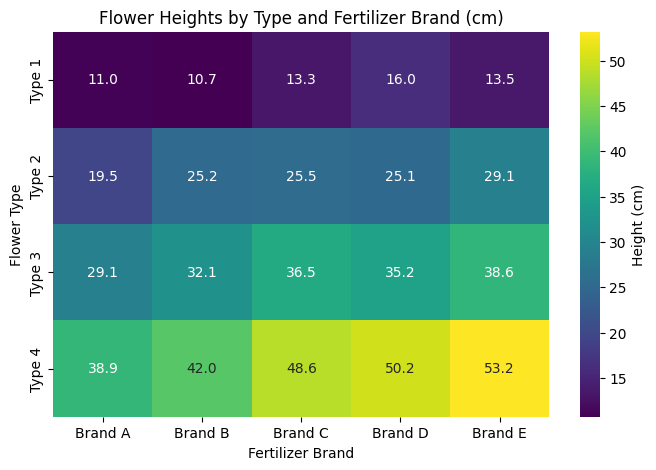

In [ ]:
from scipy.stats import chi2_contingency

np.random.seed(42)

# Create base heights for 4 different flower types
flower_bases = np.array([10, 20, 30, 40]).reshape(4, 1)

# Create multipliers for the 5 different fertilizer brands
fert_mults = np.array([1.0, 1.1, 1.2, 1.3, 1.4]).reshape(1, 5)

# Calculate the heights matrix and add slight random noise
heights_matrix = flower_bases * fert_mults + np.random.normal(0, 2, (4, 5))
heights_matrix = np.clip(heights_matrix, 1, None) # Ensure no negative heights

# Put into a DataFrame for display
df_chi = pd.DataFrame(heights_matrix, 
                      index=['Type 1', 'Type 2', 'Type 3', 'Type 4'],
                      columns=['Brand A', 'Brand B', 'Brand C', 'Brand D', 'Brand E'])

print("--- Flower Heights (cm) ---")
print(df_chi.round(2))

# Perform the Chi-squared test
chi2_stat, p_val_chi, dof, expected = chi2_contingency(heights_matrix)

print("\n--- Chi-Squared Test Results ---")
print(f"Chi2 Statistic: {chi2_stat:.4f}")
print(f"p-value:        {p_val_chi:.5e}")

print("\n!!! IMPORTANT STATISTICAL NOTE !!!")
print("The Chi-squared test is designed to test independence/association using CATEGORICAL Frequencies/Counts.")
print("Using it on continuous decimal data (like 'height in cm') is considered statistically invalid, even if the code executes.")
print("A Two-Way ANOVA would be the correct test to use for this specific table of continuous data!")

# Visualize
plt.figure(figsize=(8, 5))
sns.heatmap(df_chi, annot=True, cmap='viridis', fmt=".1f", cbar_kws={'label': 'Height (cm)'})
plt.title('Flower Heights by Type and Fertilizer Brand (cm)')
plt.ylabel('Flower Type')
plt.xlabel('Fertilizer Brand')
plt.show()

# 4. Storytelling With Data plot

Reproduce any graph of your choice in chapter nine, stopping before case study 4 (p. 206-227) of the Storytelling With Data book as best you can. You do not have to get the exact data values right, just the overall look and feel.

From Page 209

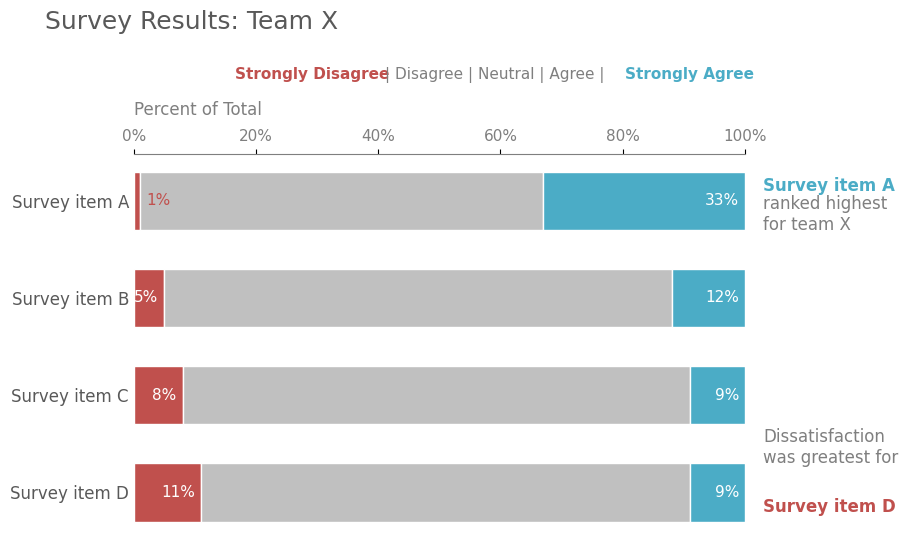

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Data 
labels = ['Survey item D', 'Survey item C', 'Survey item B', 'Survey item A']
strongly_disagree = np.array([11, 8, 5, 1])
strongly_agree = np.array([9, 9, 12, 33])
# The middle section is whatever remains out of 100%
middle = 100 - strongly_disagree - strongly_agree

# Colors
color_sd = '#c0504d'      # Red
color_mid = '#c0c0c0'     # Grey
color_sa = '#4bacc6'      # Blue
text_grey = '#7f7f7f'

# Create figure and axis
fig, ax = plt.subplots(figsize=(10, 5))

# Plot stacked bars
p1 = ax.barh(labels, strongly_disagree, color=color_sd, edgecolor='white', height=0.6)
p2 = ax.barh(labels, middle, left=strongly_disagree, color=color_mid, edgecolor='white', height=0.6)
p3 = ax.barh(labels, strongly_agree, left=strongly_disagree + middle, color=color_sa, edgecolor='white', height=0.6)

# Format the X axis to appear at the top
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')
ax.set_xlim(0, 100)
ax.set_xticks([0, 20, 40, 60, 80, 100])
ax.set_xticklabels(['0%', '20%', '40%', '60%', '80%', '100%'], color=text_grey, size=11)
ax.set_xlabel('Percent of Total', loc='left', color=text_grey, size=12, labelpad=10)

# Format the Y axis
ax.tick_params(axis='y', length=0, labelsize=12, colors='#595959')

# Remove borders, except the top one
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['top'].set_color(text_grey)

# Add custom title and legend text
fig.text(0.05, 1.05, 'Survey Results: Team X', fontsize=18, color='#595959', ha='left')
fig.text(0.24, 0.95, 'Strongly Disagree', fontsize=11, color=color_sd, weight='bold')
fig.text(0.39, 0.95, '| Disagree | Neutral | Agree |', fontsize=11, color=text_grey)
fig.text(0.63, 0.95, 'Strongly Agree', fontsize=11, color=color_sa, weight='bold')

# Add percentage labels inside/around the bars
for i, (sd, sa) in enumerate(zip(strongly_disagree, strongly_agree)):
    if sd == 1:
        # 1% is too small for the red bar, it's placed next to it
        ax.text(sd + 1, i, f'{sd}%', va='center', ha='left', color=color_sd, fontsize=11)
    else:
        # Other percentages go inside the red bar
        ax.text(sd - 1, i, f'{sd}%', va='center', ha='right', color='white', fontsize=11)
        
    ax.text(100 - 1, i, f'{sa}%', va='center', ha='right', color='white', fontsize=11)

# Add side annotations
ax.text(103, 3.1, 'Survey item A', fontsize=12, color=color_sa, weight='bold')
ax.text(103, 2.7, 'ranked highest\nfor team X', fontsize=12, color=text_grey)

ax.text(103, 0.3, 'Dissatisfaction\nwas greatest for', fontsize=12, color=text_grey)
ax.text(103, -0.2, 'Survey item D', fontsize=12, color=color_sd, weight='bold')

plt.tight_layout()
plt.subplots_adjust(top=0.8, right=0.75) 

plt.show()